In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import pandas as pd
import scipy
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib as mpl
from tqdm.auto import tqdm
import json
from multiprocessing import Pool
from functools import partial
from numpy.polynomial import Polynomial
import math

# H(187)ε (4833.5 MHz)

## Load in data

In [2]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/heatmap/052926_01/decay/1'
freq = 4833.50410957

In [3]:
info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/all_cband_info.csv').set_index('source')

Text(0, 0.5, 'Normalized Power')

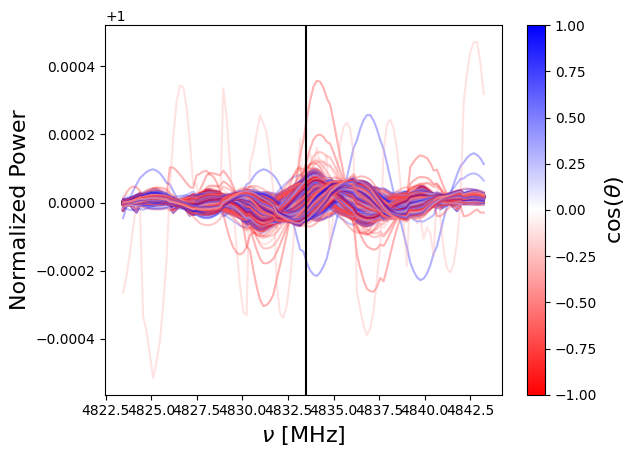

In [4]:
cmap = mpl.colormaps['bwr_r']
norm = mpl.colors.Normalize(vmin=-1, vmax=1)

fig, ax = plt.subplots()

for file in os.listdir(data_dir):
    path = os.path.join(data_dir, file)
    data = np.load(path)
    idx_min = np.argmin(np.abs(data[0] - (freq-10)))
    idx_max = np.argmin(np.abs(data[0] - (freq+10)))
    data = data[:, idx_min:idx_max]

    theta = info.loc[file[:-4], 'theta']

    ax.plot(*data, color=cmap(norm(np.cos(theta))), alpha=0.3)

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label(r'$\mathrm{cos}({\theta})$', fontsize=16)

ax.axvline(freq, c='k')

ax.set_xlabel(r'$\nu$ [MHz]', fontsize=16)
ax.set_ylabel('Normalized Power', fontsize=16)

Text(0, 0.5, 'Power [arb.]')

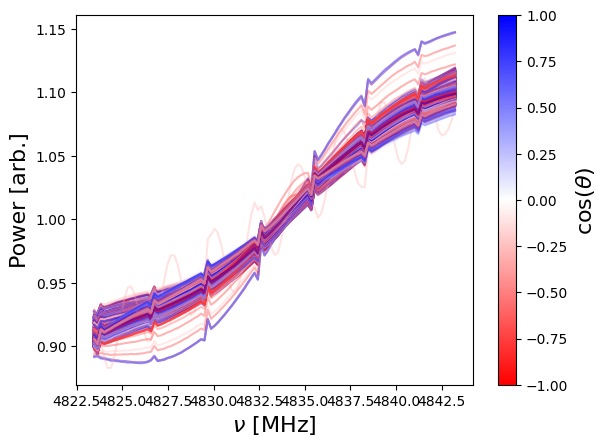

In [5]:
# Raw spectra
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/data/preprocessed/1'

fig, ax = plt.subplots()

for file in os.listdir(data_dir):
    path = os.path.join(data_dir, file)
    data = np.load(path)
    idx_min = np.argmin(np.abs(data[0] - (freq-10)))
    idx_max = np.argmin(np.abs(data[0] - (freq+10)))
    data = data[:, idx_min:idx_max]

    theta = info.loc[file[:-4], 'theta']

    ax.plot(data[0], data[1]/np.mean(data[1]), color=cmap(norm(np.cos(theta))), alpha=0.3)

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label(r'$\mathrm{cos}({\theta})$', fontsize=16)

ax.set_xlabel(r'$\nu$ [MHz]', fontsize=16)
ax.set_ylabel('Power [arb.]', fontsize=16)

## Calculate relative velocity

In [6]:
c = 299792

def relative_velocity(f):
    '''Velocity (km/s) in Earth's rest frame, given the observed frequency.'''
    return c * (freq - f) / f

def peak_freq(data_dir, file, width=5):
    path = os.path.join(data_dir, file)
    data = np.load(path)
    idx_min = np.argmin(np.abs(data[0] - (freq-width)))
    idx_max = np.argmin(np.abs(data[0] - (freq+width)))
    data = data[:, idx_min:idx_max]
    idx = np.argmax(data[1])

    return data[0, idx]

In [7]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/heatmap/052926_01/decay/1'

In [8]:
relative_velocity(peak_freq(data_dir, os.listdir(data_dir)[0]))

-80.87202255203023

In [9]:
peak_freqs = [peak_freq(data_dir, file) for file in os.listdir(data_dir)]
vels = list(map(relative_velocity, peak_freqs))

Text(0.5, 0, '$v$ [km/s]')

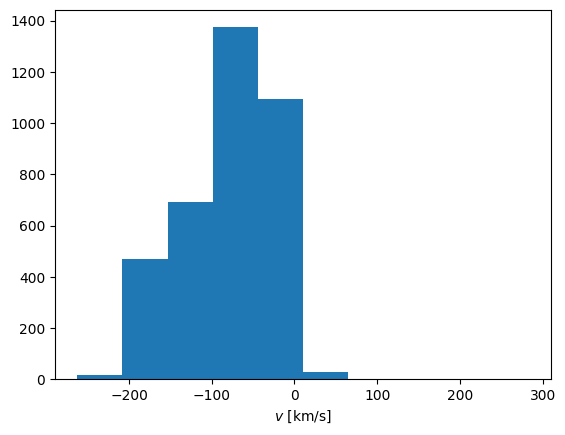

In [10]:
plt.hist(vels)
plt.xlabel('$v$ [km/s]')

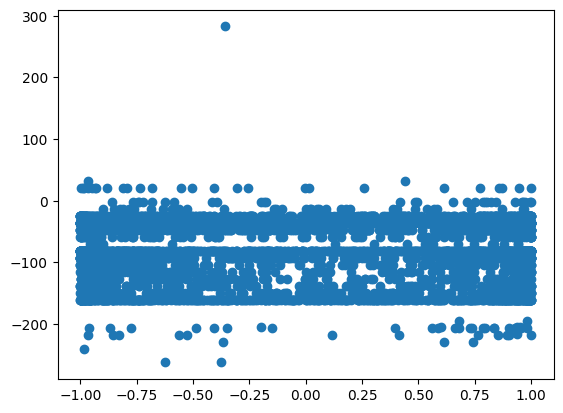

In [11]:
thetas = [info['theta'].apply(np.cos)[file[:-4]] for file in os.listdir(data_dir)]
plt.scatter(thetas, vels)

## Aitoff projection

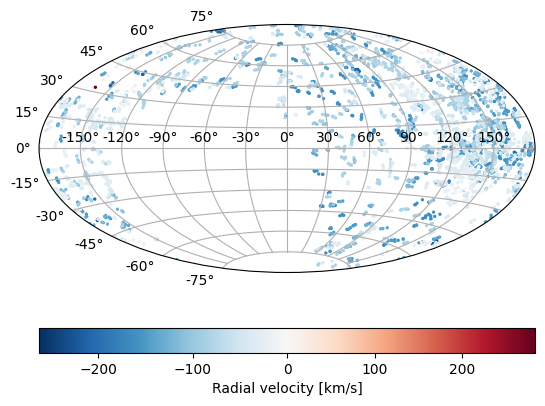

In [12]:
from astropy.coordinates import SkyCoord
import matplotlib.colors as mcolors

vel_inds = np.argsort(vels)
vels_sorted = np.array(vels)[vel_inds]
ls = np.array([info['l'][file[:-4]] for file in os.listdir(data_dir)])[vel_inds]
bs = np.array([info['b'][file[:-4]] for file in os.listdir(data_dir)])[vel_inds]
gal = SkyCoord(ls, bs, unit='deg', frame='galactic')
fig = plt.figure()
ax = fig.add_subplot(111, projection='aitoff')
ax.grid(zorder=0)
scatter = plt.scatter(gal.l.wrap_at('180d').radian, gal.b.radian,
                      c=vels_sorted, s=2, norm=mcolors.TwoSlopeNorm(vcenter = 0), zorder=1, cmap='RdBu_r')
#cax = fig.add_axes([0.1, 0.1, 0.8, 0.03])
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal')
cbar.set_label('Radial velocity [km/s]')

In [13]:
files_sorted = np.array(os.listdir(data_dir))[vel_inds]

In [14]:
for file in files_sorted[-4:]:
    name = file[:-4]
    print(f'{name}\n  Epoch: {info.loc[name, "epoch"]}\n  Time: {info.loc[name, "time"]}\n  Theta: {info.loc[name, "theta"]}')

HIP49621
  Epoch: AGBT20B_999_15
  Time: 59103_79218
  Theta: 92.1458300393721
HIP49832
  Epoch: AGBT20B_999_02
  Time: 59070_76064
  Theta: 135.35462318642743
HIP50404
  Epoch: AGBT20B_999_02
  Time: 59070_76704
  Theta: 133.06000767347555
HIP41679
  Epoch: AGBT23A_999_33
  Time: 60161_79352
  Theta: 104.87703698969808


In [15]:
np.mean(peak_freqs) - freq

1.3258461241457553

In [16]:
def relative_velocity(freq, ref):
    '''Velocity (km/s) in Earth's rest frame, given the observed frequency.'''
    return c * (ref - freq) / freq

def peak_freq(data_dir, file, width=5):
    path = os.path.join(data_dir, file)
    data = np.load(path)
    idx_min = np.argmin(np.abs(data[0] - (freq-width)))
    idx_max = np.argmin(np.abs(data[0] - (freq+width)))
    data = data[:, idx_min:idx_max]
    idx = np.argmax(data[1])

    return data[0, idx]

In [17]:
vels = [relative_velocity(peak_freq, np.mean(peak_freqs)) for peak_freq in peak_freqs]

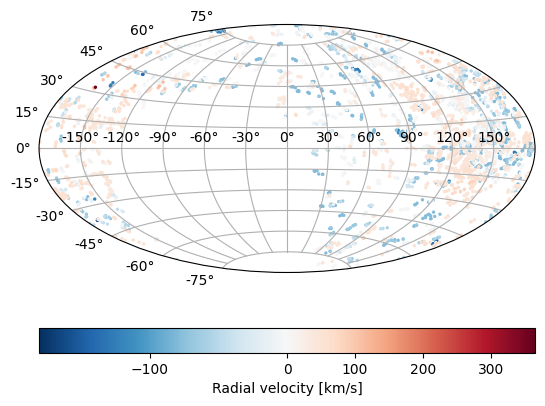

In [18]:
vel_inds = np.argsort(vels)
vels_sorted = np.array(vels)[vel_inds]
ls = np.array([info['l'][file[:-4]] for file in os.listdir(data_dir)])[vel_inds]
bs = np.array([info['b'][file[:-4]] for file in os.listdir(data_dir)])[vel_inds]
gal = SkyCoord(ls, bs, unit='deg', frame='galactic')
fig = plt.figure()
ax = fig.add_subplot(111, projection='aitoff')
ax.grid(zorder=0)
scatter = plt.scatter(gal.l.wrap_at('180d').radian, gal.b.radian,
                      c=vels_sorted, s=2, norm=mcolors.TwoSlopeNorm(vcenter = 0), zorder=1, cmap='RdBu_r')
#cax = fig.add_axes([0.1, 0.1, 0.8, 0.03])
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal')
cbar.set_label('Radial velocity [km/s]')

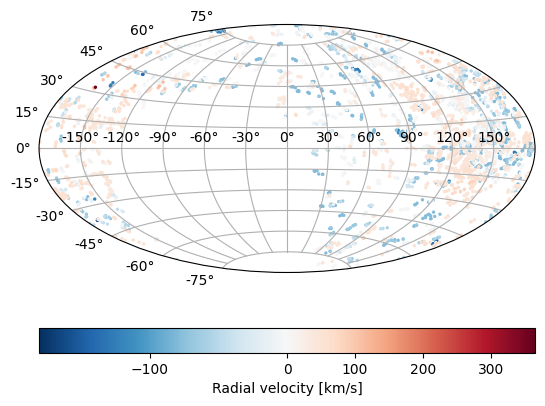

In [19]:
vel_inds = np.argsort(vels)
vels_sorted = np.array(vels)[vel_inds]
ls = np.array([info['l'][file[:-4]] for file in os.listdir(data_dir)])[vel_inds]
bs = np.array([info['b'][file[:-4]] for file in os.listdir(data_dir)])[vel_inds]
gal = SkyCoord(ls, bs, unit='deg', frame='galactic')
fig = plt.figure()
ax = fig.add_subplot(111, projection='aitoff')
ax.grid(zorder=0)
scatter = plt.scatter(gal.l.wrap_at('180d').radian, gal.b.radian,
                      c=vels_sorted, s=2, norm=mcolors.TwoSlopeNorm(vcenter = 0), zorder=1, cmap='RdBu_r')
#cax = fig.add_axes([0.1, 0.1, 0.8, 0.03])
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal')
cbar.set_label('Radial velocity [km/s]')

# # Contours
# l_ = np.linspace(-np.pi, np.pi, 1000)
# b_ = np.linspace(-np.pi/2, np.pi/2, 1000)
# L, B = np.meshgrid(l_, b_)

# def get_theta_phi(l, b):
#     galactic_coords = SkyCoord(l, b, unit='rad', frame='galactic')
#     v_sun = SkyCoord(90, 0, unit='deg', frame='galactic')
#     v_gc = SkyCoord(0, 0, unit='deg', frame='galactic')
#     theta = v_sun.separation(galactic_coords).deg
#     phi = v_gc.separation(galactic_coords).deg
#     return theta, phi

# THETA, PHI = get_theta_phi(L, B)
# theta_contour = ax.contour(L, B, (THETA-33), [0], colors='k')
# #ax.clabel(theta_contour, inline=True, fontsize=10, fmt='h')#r'$\theta=33^{\circ}$'})
# phi_contour = ax.contour(L, B, (PHI-122.999), [0], colors='gray')
# #ax.clabel(phi_contour, inline=True, fontsize=10, fmt='h')#r'$\theta=33^{\circ}$'})

In [20]:
%pip install shapely

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [22]:
l_ = np.linspace(-np.pi, np.pi, 1000)
b_ = np.linspace(-np.pi/2, np.pi/2, 1000)
L, B = np.meshgrid(l_, b_)

def get_theta_phi(l, b):
    galactic_coords = SkyCoord(l, b, unit='rad', frame='galactic')
    v_sun = SkyCoord(90, 0, unit='deg', frame='galactic')
    v_gc = SkyCoord(0, 0, unit='deg', frame='galactic')
    theta = v_sun.separation(galactic_coords).deg
    phi = v_gc.separation(galactic_coords).deg
    return theta, phi

THETA, PHI = get_theta_phi(L, B)
theta_contour = ax.contour(L, B, (THETA-33), [0], colors='k')
#ax.clabel(theta_contour, inline=True, fontsize=10, fmt='h')#r'$\theta=33^{\circ}$'})
phi_contour = ax.contour(L, B, (PHI-122.999), [0], colors='gray')
#ax.clabel(phi_contour, inline=True, fontsize=10, fmt='h')#r'$\theta=33^{\circ}$'})

In [23]:
from shapely import geometry

# 2. Extract and match intersection points
intersection_points = []

# Iterating through all disconnected path segments of Contour 1
for path1 in theta_contour.collections[0].get_paths():
    v1 = path1.vertices
    if len(v1) < 2:
        continue
    line1 = geometry.LineString(v1)
    
    # Iterating through all disconnected path segments of Contour 2
    for path2 in phi_contour.collections[0].get_paths():
        v2 = path2.vertices
        if len(v2) < 2:
            continue
        line2 = geometry.LineString(v2)
        
        # Calculate intersection between the two segments
        intersect = line1.intersection(line2)
        
        # Parse the intersection results based on type
        if not intersect.is_empty:
            if intersect.geom_type == 'Point':
                intersection_points.append((intersect.x, intersect.y))
            elif intersect.geom_type == 'MultiPoint':
                for point in intersect.geoms:
                    intersection_points.append((point.x, point.y))

intersection_points

[(2.1467427036412756, -0.0037143061524620106),
 (2.1467427036412756, 0.0037143061524617885)]

In [24]:
math.degrees(2.1467427036412756)

122.99929661914875

In [25]:
files_sorted = np.array(os.listdir(data_dir))[vel_inds]
files_sorted[-1]

'HIP41679.npy'

In [26]:
name = files_sorted[-1][:-4]
print(f'{name}\n  Epoch: {info.loc[name, "epoch"]}\n  Time: {info.loc[name, "time"]}\n  Theta: {info.loc[name, "theta"]}')

HIP41679
  Epoch: AGBT23A_999_33
  Time: 60161_79352
  Theta: 104.87703698969808


In [27]:
info['cos_theta'] = info['theta'].apply(lambda x: math.cos(math.radians(x)))
info['cos_phi'] = info['phi'].apply(lambda x: math.cos(math.radians(x)))

bins = np.linspace(-1, 1, 50+1)
info['cos_theta_bin'] = pd.cut(info['cos_theta'], bins, labels=False)
info['cos_phi_bin'] = pd.cut(info['cos_phi'], bins, labels=False)

In [28]:
bins

array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
       -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
       -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
        0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
        0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
        0.8 ,  0.84,  0.88,  0.92,  0.96,  1.  ])

In [29]:
sorted(list(set(info['cos_theta_bin'])))

[4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49]

In [30]:
info[(info['cos_theta_bin']==45) & (info['cos_phi_bin']==11)]

,epoch,time,ra,dec,l,b,theta,phi,nfw,nfw_sq,iso,iso_sq,burkert,burkert_sq,moore,moore_sq,cos_theta,cos_phi,cos_theta_bin,cos_phi_bin
source,,,,,,,,,,,,,,,,,,,,
HIP4466,AGBT20B_999_04,59075_58157,14.3093,54.9433,123.772642,-7.918981,34.581155,123.408024,1.189038e+08,6.649520e+14,2.765379e+08,1.363452e+15,1.026261e+08,5.417944e+14,2.640962e+07,3.907196e+13,0.823323,-0.550598,45,11
HIP4183,AGBT20B_999_04,59075_57528,13.4455,54.4872,123.276009,-8.382982,34.197542,122.875175,1.193195e+08,6.688961e+14,2.770321e+08,1.368173e+15,1.029996e+08,5.449620e+14,2.651203e+07,3.931912e+13,0.827105,-0.542811,45,11
HIP3996,AGBT20B_999_04,59075_58790,12.8200,53.7688,122.908294,-9.102940,34.007150,122.442542,1.196613e+08,6.721483e+14,2.774371e+08,1.372050e+15,1.033066e+08,5.475730e+14,2.659626e+07,3.952305e+13,0.828968,-0.536454,45,11
HIP4437,AGBT20B_999_04,59075_60093,14.1386,60.0269,123.571711,-2.838492,33.677482,123.525069,1.188132e+08,6.640946e+14,2.764301e+08,1.362423e+15,1.025448e+08,5.411056e+14,2.638732e+07,3.901825e+13,0.832172,-0.552302,45,11
HIP3930,AGBT20B_999_04,59075_59450,12.6166,59.4945,122.808421,-3.377015,32.962432,122.744305,1.194225e+08,6.698751e+14,2.771542e+08,1.369342e+15,1.030921e+08,5.457481e+14,2.653741e+07,3.938050e+13,0.839028,-0.540891,45,11
HIP4182,AGBT20A_999_20,58955_75592,13.3965,60.6679,123.195188,-2.202750,33.259843,123.167493,1.190907e+08,6.667240e+14,2.767604e+08,1.365576e+15,1.027941e+08,5.432177e+14,2.645567e+07,3.918299e+13,0.836192,-0.547088,45,11
HIP4295,AGBT20A_999_20,58955_78792,13.7308,61.6597,123.345628,-1.209248,33.365015,123.337232,1.189587e+08,6.654721e+14,2.766033e+08,1.364076e+15,1.026755e+08,5.422122e+14,2.642314e+07,3.910454e+13,0.835184,-0.549566,45,11
HIP4440,AGBT20A_999_20,58955_82182,14.1840,60.3482,123.587792,-2.516800,33.670925,123.551096,1.187931e+08,6.639044e+14,2.764061e+08,1.362195e+15,1.025267e+08,5.409528e+14,2.638237e+07,3.900633e+13,0.832236,-0.552680,45,11
HIP4412,AGBT20A_999_20,58955_81525,14.0990,62.3245,123.507628,-0.541705,33.511496,123.505933,1.188280e+08,6.642345e+14,2.764477e+08,1.362591e+15,1.025581e+08,5.412180e+14,2.639096e+07,3.902701e+13,0.833775,-0.552023,45,11


# He(149)δ (7645.9 MHz)

Text(0, 0.5, 'Normalized Power')

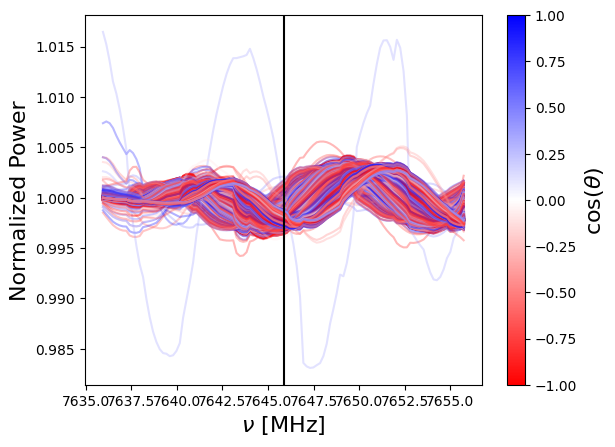

In [31]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/heatmap/052926_01/decay/3'
freq = 7645.87202539
info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/all_cband_info.csv').set_index('source')

cmap = mpl.colormaps['bwr_r']
norm = mpl.colors.Normalize(vmin=-1, vmax=1)

fig, ax = plt.subplots()

for file in os.listdir(data_dir):
    path = os.path.join(data_dir, file)
    data = np.load(path)
    idx_min = np.argmin(np.abs(data[0] - (freq-10)))
    idx_max = np.argmin(np.abs(data[0] - (freq+10)))
    data = data[:, idx_min:idx_max]

    theta = info.loc[file[:-4], 'theta']

    ax.plot(*data, color=cmap(norm(np.cos(theta))), alpha=0.3)

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label(r'$\mathrm{cos}({\theta})$', fontsize=16)

ax.axvline(freq, c='k')

ax.set_xlabel(r'$\nu$ [MHz]', fontsize=16)
ax.set_ylabel('Normalized Power', fontsize=16)

In [32]:
c = 299792

def relative_velocity(freq, ref):
    '''Velocity (km/s) in Earth's rest frame, given the observed frequency.'''
    return c * (ref - freq) / freq

def peak_freq(data_dir, file, width=10):
    path = os.path.join(data_dir, file)
    data = np.load(path)
    idx_min = np.argmin(np.abs(data[0] - (freq-width)))
    idx_max = np.argmin(np.abs(data[0] - (freq+width)))
    data = data[:, idx_min:idx_max]
    idx = np.argmax(data[1])

    return data[0, idx]

In [33]:
peak_freqs = [peak_freq(data_dir, file) for file in os.listdir(data_dir)]

In [34]:
np.mean(peak_freqs) - freq

4.26592427038031

In [35]:
vels_off = [relative_velocity(peak_freq, freq) for peak_freq in peak_freqs]
vels = [relative_velocity(peak_freq, np.mean(peak_freqs)) for peak_freq in peak_freqs]

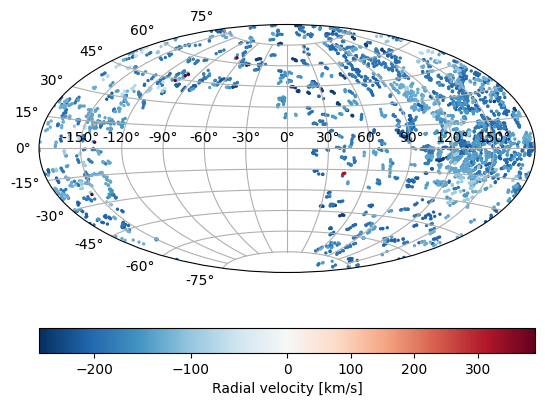

In [36]:
vel_inds = np.argsort(vels_off)
vels_sorted = np.array(vels_off)[vel_inds]
ls = np.array([info['l'][file[:-4]] for file in os.listdir(data_dir)])[vel_inds]
bs = np.array([info['b'][file[:-4]] for file in os.listdir(data_dir)])[vel_inds]
gal = SkyCoord(ls, bs, unit='deg', frame='galactic')
fig = plt.figure()
ax = fig.add_subplot(111, projection='aitoff')
ax.grid(zorder=0)
scatter = plt.scatter(gal.l.wrap_at('180d').radian, gal.b.radian,
                      c=vels_sorted, s=2, norm=mcolors.TwoSlopeNorm(vcenter = 0), zorder=1, cmap='RdBu_r')
#cax = fig.add_axes([0.1, 0.1, 0.8, 0.03])
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal')
cbar.set_label('Radial velocity [km/s]')

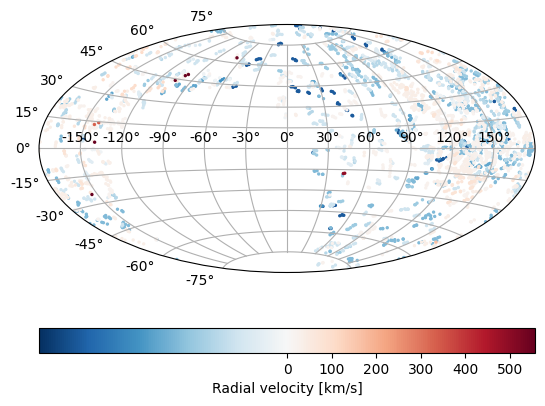

In [37]:
vel_inds = np.argsort(vels)
vels_sorted = np.array(vels)[vel_inds]
ls = np.array([info['l'][file[:-4]] for file in os.listdir(data_dir)])[vel_inds]
bs = np.array([info['b'][file[:-4]] for file in os.listdir(data_dir)])[vel_inds]
gal = SkyCoord(ls, bs, unit='deg', frame='galactic')
fig = plt.figure()
ax = fig.add_subplot(111, projection='aitoff')
ax.grid(zorder=0)
scatter = plt.scatter(gal.l.wrap_at('180d').radian, gal.b.radian,
                      c=vels_sorted, s=2, norm=mcolors.TwoSlopeNorm(vcenter = 0), zorder=1, cmap='RdBu_r')
#cax = fig.add_axes([0.1, 0.1, 0.8, 0.03])
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal')
cbar.set_label('Radial velocity [km/s]')

## Contours

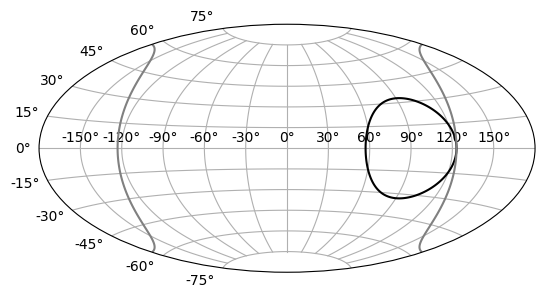

In [38]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='aitoff')
ax.grid(zorder=0)

l_ = np.linspace(-np.pi, np.pi, 1000)
b_ = np.linspace(-np.pi/2, np.pi/2, 1000)
L, B = np.meshgrid(l_, b_)

def get_theta_phi(l, b):
    galactic_coords = SkyCoord(l, b, unit='rad', frame='galactic')
    v_sun = SkyCoord(90, 0, unit='deg', frame='galactic')
    v_gc = SkyCoord(0, 0, unit='deg', frame='galactic')
    theta = v_sun.separation(galactic_coords).deg
    phi = v_gc.separation(galactic_coords).deg
    return theta, phi

THETA, PHI = get_theta_phi(L, B)
theta_contour = ax.contour(L, B, (THETA-33), [0], colors='k')
#ax.clabel(theta_contour, inline=True, fontsize=10, fmt='h')#r'$\theta=33^{\circ}$'})
phi_contour = ax.contour(L, B, (PHI-122.999), [0], colors='gray')
#ax.clabel(phi_contour, inline=True, fontsize=10, fmt='h')#r'$\theta=33^{\circ}$'})